In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

In [ ]:
df = pd.read_csv("smart_grid_stability_augmented.csv")

print(df.shape)
df.head()

(60000, 14)


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['stabf'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    60000 non-null  float64
 1   tau2    60000 non-null  float64
 2   tau3    60000 non-null  float64
 3   tau4    60000 non-null  float64
 4   p1      60000 non-null  float64
 5   p2      60000 non-null  float64
 6   p3      60000 non-null  float64
 7   p4      60000 non-null  float64
 8   g1      60000 non-null  float64
 9   g2      60000 non-null  float64
 10  g3      60000 non-null  float64
 11  g4      60000 non-null  float64
 12  stab    60000 non-null  float64
 13  stabf   60000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 6.4+ MB
None

Missing Values:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Class Distribution:
stabf
unstable    38280
stable      

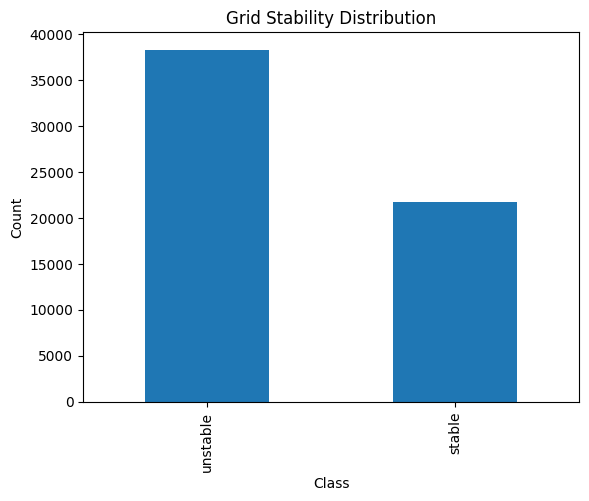

In [ ]:
df['stabf'].value_counts().plot(kind='bar')

plt.title("Grid Stability Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
!pip install streamlit


: 

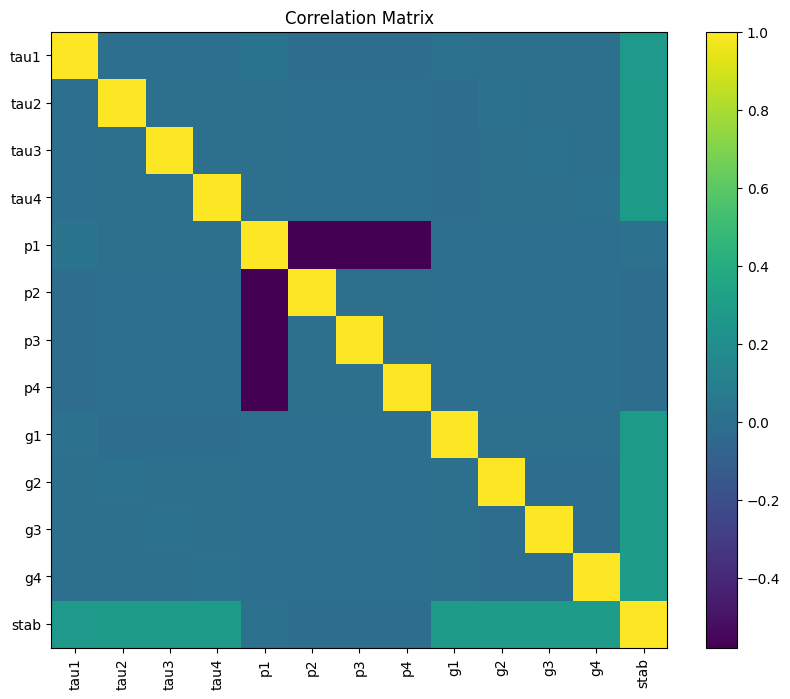

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df.drop(['stab','stabf'], axis=1)

y = df['stabf'].map({
    'stable':1,
    'unstable':0
})

print(X.shape)

(60000, 12)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.8135833333333333
[[6718  938]
 [1299 3045]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      7656
           1       0.76      0.70      0.73      4344

    accuracy                           0.81     12000
   macro avg       0.80      0.79      0.79     12000
weighted avg       0.81      0.81      0.81     12000



In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy: 0.8914166666666666
[[7013  643]
 [ 660 3684]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      7656
           1       0.85      0.85      0.85      4344

    accuracy                           0.89     12000
   macro avg       0.88      0.88      0.88     12000
weighted avg       0.89      0.89      0.89     12000



In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.9458333333333333
[[7433  223]
 [ 427 3917]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7656
           1       0.95      0.90      0.92      4344

    accuracy                           0.95     12000
   macro avg       0.95      0.94      0.94     12000
weighted avg       0.95      0.95      0.95     12000



In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

   Feature  Importance
0     tau1    0.129065
3     tau4    0.127094
1     tau2    0.126136
2     tau3    0.125481
8       g1    0.101889
11      g4    0.100614
10      g3    0.099834
9       g2    0.097661
4       p1    0.024734
5       p2    0.022549
6       p3    0.022546
7       p4    0.022397


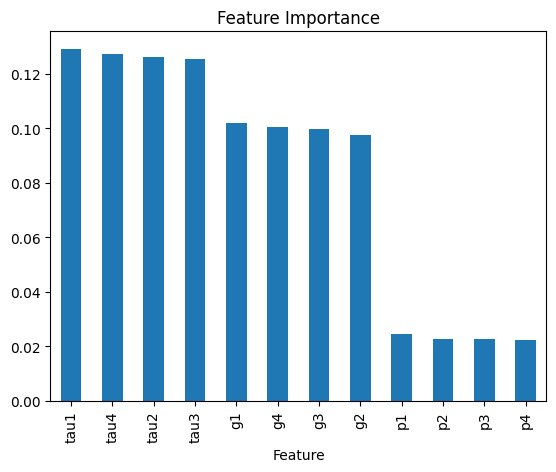

In [ ]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    legend=False
)

plt.title("Feature Importance")

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)   

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy: 0.9799166666666667
[[7557   99]
 [ 142 4202]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7656
           1       0.98      0.97      0.97      4344

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



In [ ]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

print(results)



                 Model  Accuracy
0  Logistic Regression  0.813583
1        Decision Tree  0.891417
2        Random Forest  0.945833
3              XGBoost  0.979917


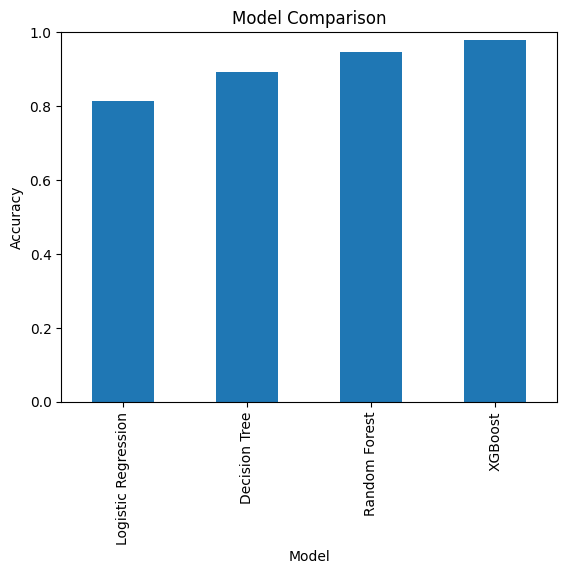

In [ ]:
results.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False
)

plt.ylim(0,1)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
pickle.dump(
    rf,
    open("best_model.pkl","wb")
)

pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

print("Model Saved")

Model Saved


In [ ]:
print(confusion_matrix(y_test, xgb_pred))

[[7557   99]
 [ 142 4202]]


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    ).head()
)

   Feature  Importance
2     tau3    0.135226
1     tau2    0.134568
3     tau4    0.131263
9       g2    0.120389
10      g3    0.116431
